In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

LOAD THE DATASET


In [2]:
file_path = r'/content/preprocessed_demand_data (1) (2).csv'
df = pd.read_csv(file_path)

Convert the Date column to datetime format and sort the data by date

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


/tmp/ipykernel_866/2817343.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


FEATURE SELECTION AND ONE-HOT ENCODING

In [4]:
target = 'OrderCount'

Remove NumberOfPieces and TotalRevenue to avoid data leakage

In [5]:
features = [
    'Holiday_Indicator_Encoded', 'Festival_Name_Encoded', 'Season_Encoded',
    'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'Quarter',
    'OrderCount_lag_1', 'OrderCount_lag_7', 'OrderCount_lag_14',
    'OrderCount_rolling_mean_7', 'OrderCount_rolling_std_7'
]


Convert categorical columns (Hub and Region) into numeric format using One-Hot Encoding

In [6]:
df_encoded = pd.get_dummies(df, columns=['Hub', 'Region'], drop_first=True)

Select all input features except the target, date, and leakage columns

In [7]:
all_features = [
    col for col in df_encoded.columns
    if col != target and col != 'Date'
    and col not in ['NumberOfPieces', 'TotalRevenue']
]

X = df_encoded[all_features]
y = df_encoded[target]


SPLIT THE DATA INTO TRAINING AND TEST SETS

In [8]:
split_idx = int(len(df_encoded) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

TRAIN THE RANDOM FOREST MODEL


In [9]:
print("Training Random Forest model... (This might take a few seconds)")


Training Random Forest model... (This might take a few seconds)


In [10]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

Train the model

In [11]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

MAKE PREDICTIONS AND EVALUATE THE MODEL

In [12]:
y_pred = model.predict(X_test)

Calculate evaluation metrics

In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
print("\n--- Random Forest Model Evaluation ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Model Accuracy: {accuracy:.2f}%")



--- Random Forest Model Evaluation ---
RMSE: 67.7120
MAE: 46.7667
R2 Score: 0.8950
Model Accuracy: 89.50%


FIND FEATURE IMPORTANCE

In [15]:
importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Important Features ---")
print(importance.head(5))


--- Top 5 Important Features ---
                      Feature  Importance
6                   DayOfWeek    0.588652
13  OrderCount_rolling_mean_7    0.212166
11           OrderCount_lag_7    0.131293
3                        Year    0.010881
8                   IsWeekend    0.009024


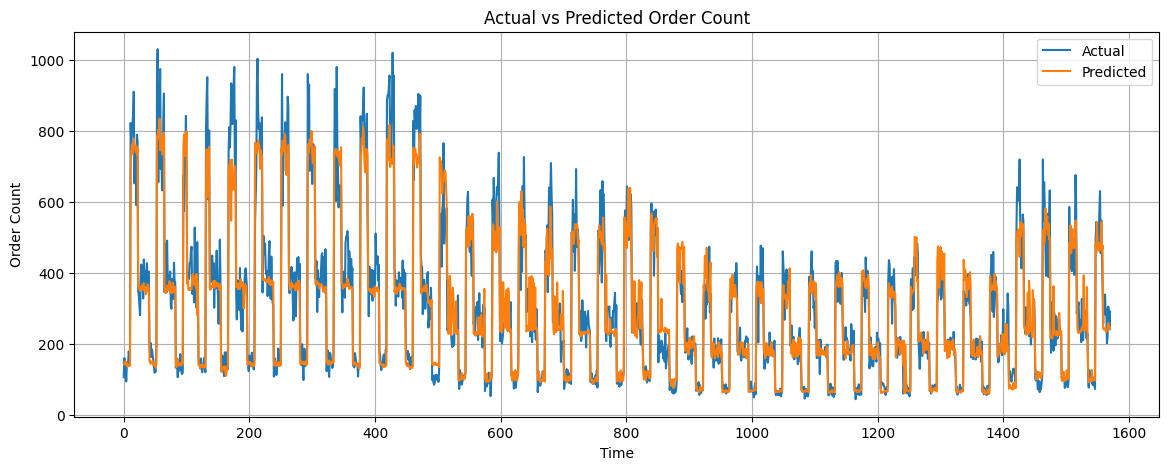

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.values,label='Actual')
plt.plot(y_pred,label='Predicted')
plt.title("Actual vs Predicted Order Count")
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.legend()
plt.grid(True)
plt.show()

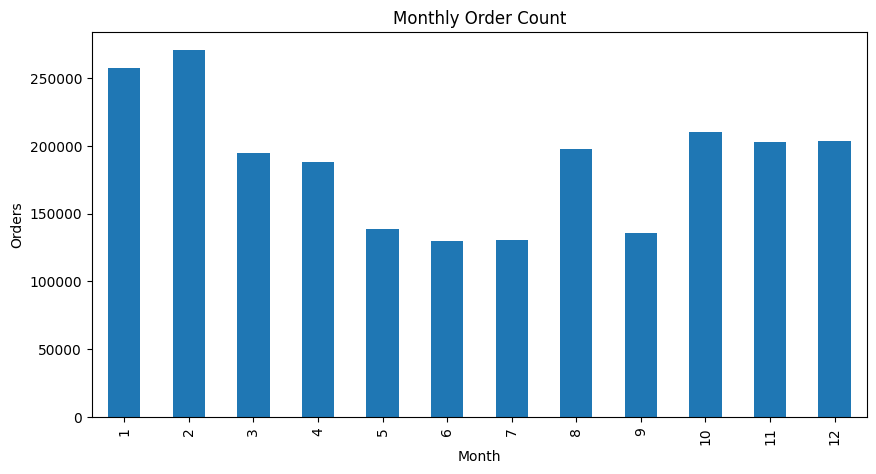

In [17]:
monthly=df.groupby('Month')['OrderCount'].sum()

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')
plt.title("Monthly Order Count")
plt.ylabel("Orders")
plt.show()

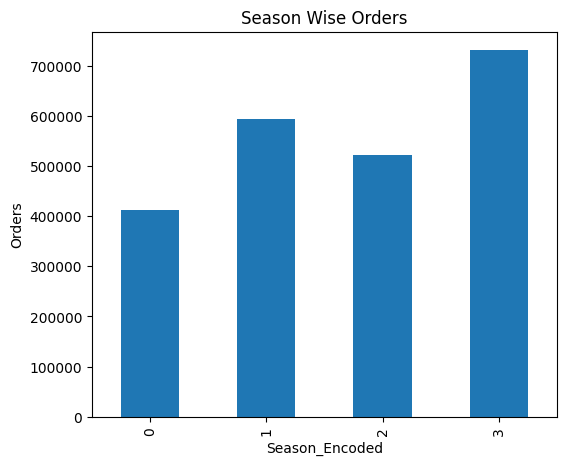

In [18]:
season=df.groupby('Season_Encoded')['OrderCount'].sum()

plt.figure(figsize=(6,5))
season.plot(kind='bar')
plt.title("Season Wise Orders")
plt.ylabel("Orders")
plt.show()

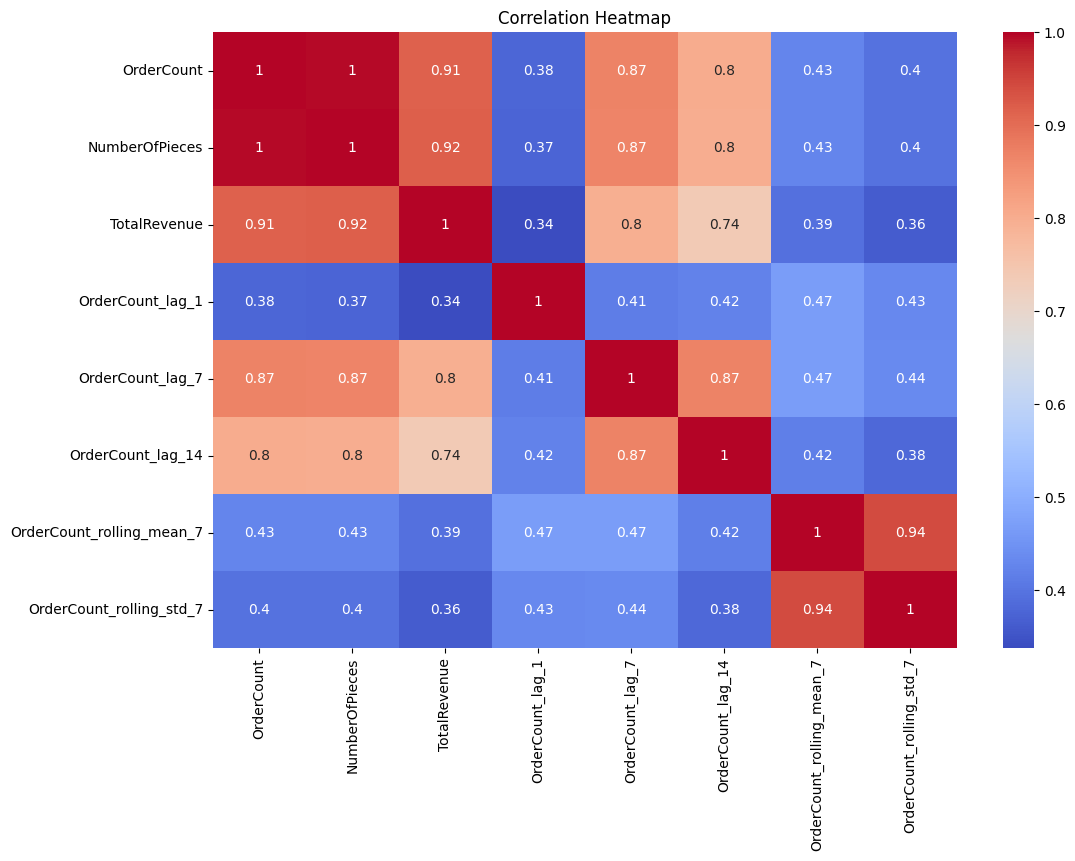

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df[['OrderCount',
           'NumberOfPieces',
           'TotalRevenue',
           'OrderCount_lag_1',
           'OrderCount_lag_7',
           'OrderCount_lag_14',
           'OrderCount_rolling_mean_7',
           'OrderCount_rolling_std_7']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()